In [1]:
!python --version

Python 3.14.0


The system cannot find the path specified.


In [3]:
import numpy as np
from numpy.typing import NDArray
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import scale

In [2]:
# root traits - total root length (TRL), average root diameter (ARD) and root surface area (RSA) and root volume (RV)
# hyphal traits - hyphal diameter (HD), hyphal branching angle (HBA) and internodal hyphal length (IHL)

In [4]:
def plot_scatters_and_regression_results(ax: plt.Axes, x_min: float, x_max: float, x_size:int, sample_size:int, scale: float,
                                         title: str, markersize:int, colours: tuple[str] = ("teal", "purple", "crimson", "orange", "green", "blue")) -> plt.Axes:
    """
    """
    x = np.random.choice(a=np.linspace(start=x_min, stop=x_max, num=x_size), size=sample_size, replace=False)
    x.sort()
    ax.set_title(title)
    # ax.set_aspect("equal", adjustable="box")
    # ax.plot(x, x, c="black", linestyle="dotted") # plot the diagonal
    for i, col in enumerate(colours):
        
        y = x + np.random.normal(loc=0, scale=scale, size=x.shape) # bogus measurements, must be really close to x!!!!
        ax.scatter(x=x, y=y, s=markersize, c=col, edgecolor="black")
        
        lm = LinearRegression().fit(x.reshape(-1, 1), y) # fit the model for "actual" measurements and bogus measurements
        y_pred = lm.coef_ * x + lm.intercept_  # predicted measurements based on parameters inferred from the bogus measurements
        # corr = pearsonr(x, y_pred + np.random.rand(*y_pred.shape))[0] # add a bit of jitter and calculate the correlation between the bogus measurements and predictions
        ax.plot(x, y_pred, color=col, label=f"$R^2 (M_{i})={np.random.randint(low=800, high=1000)/1000.0:.4f}$", marker="none")
        ax.legend(loc="upper left")

    return ax

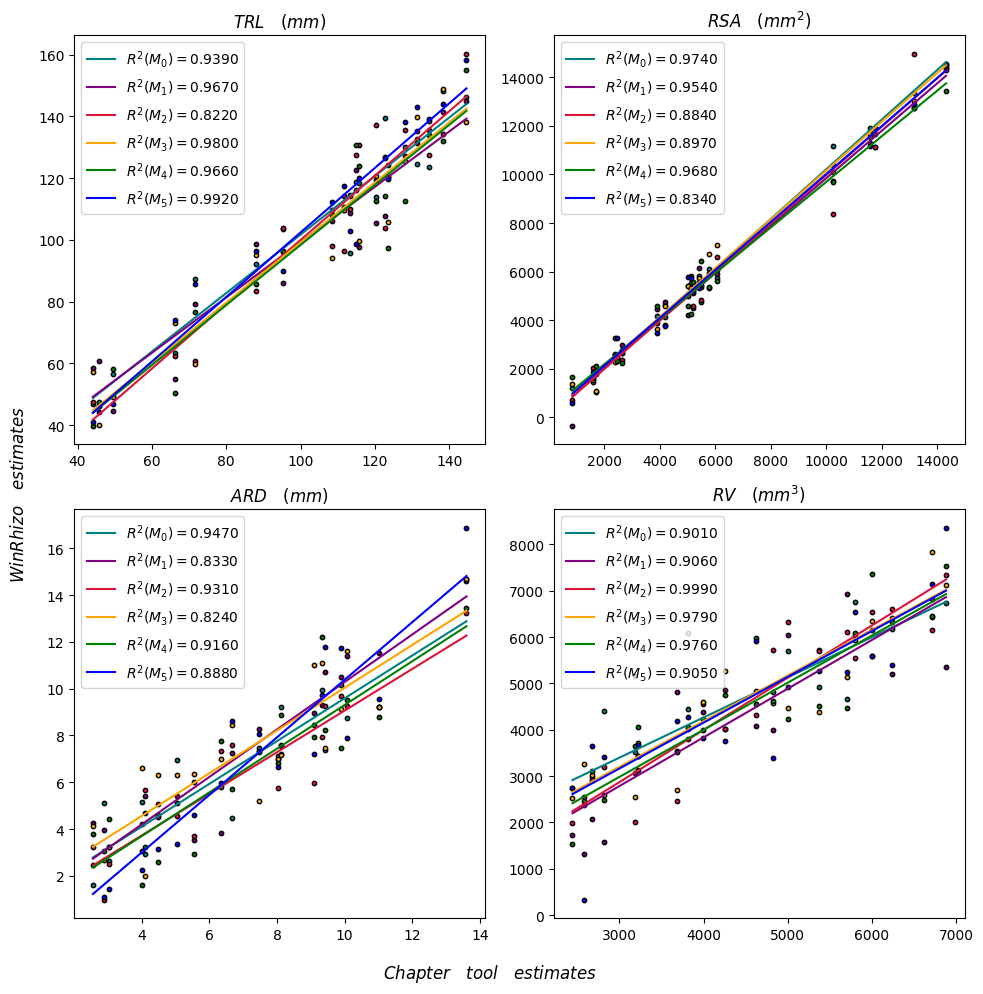

In [48]:
fig, axes = plt.subplots(ncols=2, nrows=2)
axis_0, axis_1, axis_2, axis_3 = axes.flatten()
fig.set_size_inches(10, 10)

plot_scatters_and_regression_results(ax=axis_0, x_min=30, x_max=147, x_size=150, scale=10, sample_size=20, title=r"$TRL\hspace{1}(mm)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_1, x_min=753, x_max=14897, x_size=150, scale=500, sample_size=20, title=r"$RSA\hspace{1}(mm^2)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_2, x_min=2, x_max=14, x_size=150, scale=1.5, sample_size=20, title=r"$ARD\hspace{1}(mm)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_3, x_min=2142, x_max=7147, x_size=150, scale=693, sample_size=20, title=r"$RV\hspace{1}(mm^3)$", markersize=10)

fig.supxlabel(r"$Chapter\hspace{1}tool\hspace{1}estimates$")
fig.supylabel(r"$WinRhizo\hspace{1}estimates$")

plt.tight_layout()
plt.show()
# plt.savefig(r"../../plots/rtestimates.png", dpi=400, transparent=True)

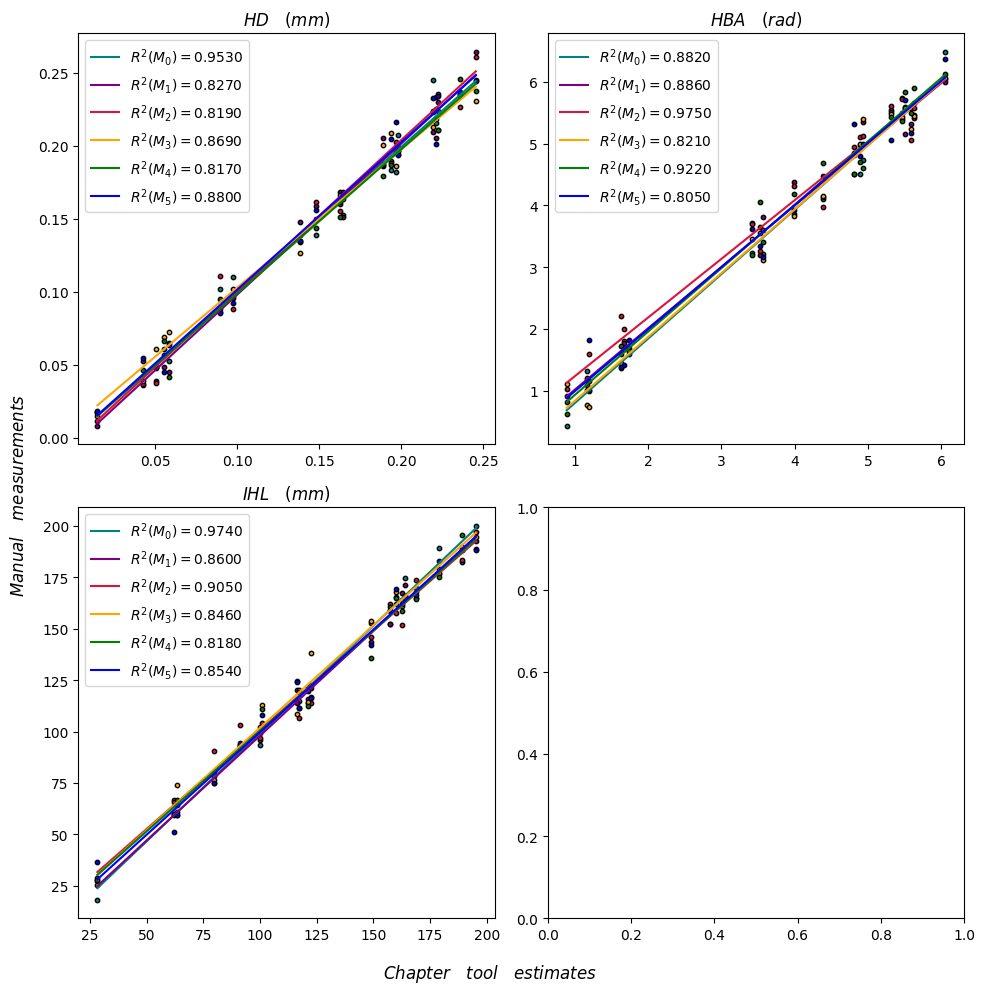

In [7]:
fig, axes = plt.subplots(ncols=2, nrows=2)
fig.set_size_inches(10, 10)
axis_0, axis_1, axis_2, _ = axes.flatten()

plot_scatters_and_regression_results(ax=axis_0, x_min=0.005, x_max=0.247, x_size=150, scale=0.010, sample_size=20, title=r"$HD\hspace{1}(mm)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_1, x_min=0.5, x_max=2*np.pi, x_size=150, scale=0.25, sample_size=20, title=r"$HBA\hspace{1}(rad)$", markersize=10)
plot_scatters_and_regression_results(ax=axis_2, x_min=27, x_max=214, x_size=150, scale=5.5, sample_size=20, title=r"$IHL\hspace{1}(mm)$", markersize=10)

fig.supxlabel(r"$Chapter\hspace{1}tool\hspace{1}estimates$")
fig.supylabel(r"$Manual\hspace{1}measurements$")

plt.tight_layout()
plt.show()
# plt.savefig(fname=r"../../plots/hyphaltraits.png", dpi=400, transparent=True)